# Анализ отзывов клиентов мебельных компаний

Цель проекта — выявить потребности и болевые точки клиентов на основе текстовых отзывов и проверить 5 бизнес-гипотез.

## 1. Загрузка библиотек и данных

In [1]:
import pandas as pd
import numpy as np
import re
from math import sqrt
import scipy.stats as st
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

DATA_PATHS = {
    "2GIS": "reviews_2gis.xlsx",
    "Google": "reviews_google.xlsx",
    "Yandex": "reviews_yandex (1).xlsx",
}

In [2]:
dfs = []
for source, path in DATA_PATHS.items():
    part = pd.read_excel(path)
    part["Источник"] = source
    dfs.append(part)

df_raw = pd.concat(dfs, ignore_index=True)
print(df_raw.shape)
df_raw.head()

(12905, 14)


,Наименование,Оценка,Количество оценок,Адрес,Координаты объекта,Количество отзывов,Автор,Статус автора,Оценка автора,Дата,Текст,Like,Dislike,Источник
0,DaVita-мебель,5.0,34 оценки,"ТЦ Акцент, Октябрьской Революции, 1 к7а, Иркутск","104.295113,52.292791",30.0,Olesya Olesya,4 отзыва,5.0,6 марта 2024,Купили в вашем салоне шкаф для одежды ‘Фреска’\nОчень довольны качеством изделия .Доводчики супер 🔥 Вовремя привезли...,0.0,NaN,2GIS
1,DaVita-мебель,5.0,34 оценки,"ТЦ Акцент, Октябрьской Революции, 1 к7а, Иркутск","104.295113,52.292791",30.0,Кристина Богданова,2 отзыва,5.0,3 марта 2024,Большое спасибо! Персонал всегда подскажет и поможет с выбором.,1.0,NaN,2GIS
2,DaVita-мебель,5.0,34 оценки,"ТЦ Акцент, Октябрьской Революции, 1 к7а, Иркутск","104.295113,52.292791",30.0,Анатолий Александрович,1 отзыв,5.0,28 февраля 2024,"Брали у вас спальню Тиффани, довольны качеством и сроками доставки. Спасибо!",2.0,NaN,2GIS
3,DaVita-мебель,5.0,34 оценки,"ТЦ Акцент, Октябрьской Революции, 1 к7а, Иркутск","104.295113,52.292791",30.0,Сергей Сергеевич,1 отзыв,5.0,23 февраля 2024,"Мне понравилось что можно заказать кухню сегодня и установят тебе её буквально на этой же неделе, в отличии от многи...",0.0,NaN,2GIS
4,DaVita-мебель,5.0,34 оценки,"ТЦ Акцент, Октябрьской Революции, 1 к7а, Иркутск","104.295113,52.292791",30.0,Алена,12 отзывов,5.0,30 января 2024,"Хочу поблагодарить компанию Davita-мебель! Детская красивая,стильная, ребенок до сих пор радуется каждый раз!\nДоста...",1.0,NaN,2GIS


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Очистка и подготовка признаков

Важно: для проверки гипотез используется `Оценка автора`, то есть оценка конкретного отзыва, а не общая оценка организации.

In [3]:
def parse_rating(x):

    if pd.isna(x):
        return np.nan
    s = str(x).lower().replace('\xa0', ' ')
    m = re.search(r'(\d+[\.,]?\d*)', s)
    if not m:
        return np.nan
    val = float(m.group(1).replace(',', '.'))
    if val > 5 and val <= 10:
        val = val / 2
    return val


df = df_raw.copy()
df['rating_org'] = df['Оценка'].apply(parse_rating)
df['rating'] = df['Оценка автора'].apply(parse_rating)
df['text'] = df['Текст'].astype(str).str.replace('\n', ' ', regex=False).str.strip()

df = df[df['Текст'].notna()]
df = df[df['text'].str.len() > 5]
df = df.drop_duplicates(subset=['Источник', 'Наименование', 'Автор', 'Дата', 'text', 'rating'])

df['text_lower'] = df['text'].str.lower()
df['word_count'] = df['text_lower'].str.findall(r'[а-яёa-z0-9]+').str.len()
df['char_count'] = df['text'].str.len()
df['exclamations'] = df['text'].str.count('!')
df['emoji_count'] = df['text'].str.count(r'[🔥😊🙂😍😡👍👎❤❤️😂😭😉😞😔😅😁]')
df['sentiment_by_rating'] = np.select([df['rating'] >= 4, df['rating'] <= 2], ['positive', 'negative'], default='neutral')

print(df.shape)
df[['Источник','Наименование','Оценка автора','rating','text','word_count']].head()

(11622, 23)


,Источник,Наименование,Оценка автора,rating,text,word_count
0,2GIS,DaVita-мебель,5.0,5.0,Купили в вашем салоне шкаф для одежды ‘Фреска’ Очень довольны качеством изделия .Доводчики супер 🔥 Вовремя привезли ...,27
1,2GIS,DaVita-мебель,5.0,5.0,Большое спасибо! Персонал всегда подскажет и поможет с выбором.,9
2,2GIS,DaVita-мебель,5.0,5.0,"Брали у вас спальню Тиффани, довольны качеством и сроками доставки. Спасибо!",11
3,2GIS,DaVita-мебель,5.0,5.0,"Мне понравилось что можно заказать кухню сегодня и установят тебе её буквально на этой же неделе, в отличии от многи...",58
4,2GIS,DaVita-мебель,5.0,5.0,"Хочу поблагодарить компанию Davita-мебель! Детская красивая,стильная, ребенок до сих пор радуется каждый раз! Достав...",39


## 3. Словари тем и дополнительные признаки

In [4]:
patterns = {
    'cat_service': r'\b(сервис|обслуживан\w*|персонал|продав\w*|консультант\w*|менеджер\w*|сотрудник\w*|хам\w*|груб\w*|вежлив\w*|помог\w*|отношени\w*|клиент\w*|салон)\b',
    'cat_quality': r'\b(качество|качествен\w*|брак|сломал\w*|полом\w*|дефект\w*|царапин\w*|скол\w*|трещин\w*|развал\w*|крив\w*|плох\w*|материал\w*|фурнитур\w*|петл\w*|доводчик\w*)\b',
    'cat_delivery': r'\b(достав\w*|привез\w*|курьер\w*|логист\w*|срок\w*|задерж\w*|опозда\w*|вовремя|быстро|долго|ждал\w*|месяц\w*)\b',
    'cat_description_mismatch': r'\b(описани\w*|не соответств\w*|несоответств\w*|не такой|не та|не то|другой цвет|цвет отлич\w*|размер\w* не|ожидан\w*|на фото|фото|картинк\w*|образец\w*)\b',
    'cat_return_claim': r'\b(возврат\w*|вернуть|вернули|претензи\w*|жалоб\w*|заявлени\w*|гаранти\w*|обмен\w*|ремонт\w*|компенсац\w*|деньг\w* назад)\b',
    'cat_price': r'\b(цен\w*|стоимост\w*|дорог\w*|дешев\w*|скидк\w*|рассрочк\w*|предоплат\w*)\b',
}

for col, pat in patterns.items():
    df[col] = df['text_lower'].str.contains(pat, regex=True, na=False)

fast_pat = r'\b(быстро|быстрая|быстрые|оперативно|вовремя|в срок|раньше срока|сразу|без задерж\w*)\b'
slow_pat = r'\b(долго|задерж\w*|опозда\w*|ждал\w*|ждали|месяц\w*|недел\w*|перенос\w*|сорвал\w* срок\w*)\b'
df['delivery_fast'] = df['cat_delivery'] & df['text_lower'].str.contains(fast_pat, regex=True, na=False)
df['delivery_slow'] = df['cat_delivery'] & df['text_lower'].str.contains(slow_pat, regex=True, na=False)

soft_pat = r'\b(диван\w*|кресл\w*|пуф\w*|тахт\w*|соф\w*|матрас\w*)\b'
case_pat = r'\b(шкаф\w*|кухн\w*|гарнитур\w*|стол\w*|стул\w*|комод\w*|тумб\w*|кровать\w*|стеллаж\w*|полк\w*|прихож\w*|корпус\w*)\b'
df['furniture_soft'] = df['text_lower'].str.contains(soft_pat, regex=True, na=False)
df['furniture_case'] = df['text_lower'].str.contains(case_pat, regex=True, na=False)

emotion_pat = r'\b(ужас\w*|кошмар\w*|отличн\w*|прекрасн\w*|супер|разочар\w*|довол\w*|рад\w*|спасибо|благодар\w*|ненавиж\w*|обман\w*|позор|восторг\w*|рекоменд\w*|никогда)\b'
df['emotion_words'] = df['text_lower'].str.findall(emotion_pat).str.len()
df['emotion_score'] = df['emotion_words'] + df['exclamations'] + df['emoji_count']

df[['rating','sentiment_by_rating','cat_service','cat_quality','cat_delivery','delivery_fast','delivery_slow','word_count','emotion_score']].head()

/tmp/ipykernel_1234/4177123458.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[col] = df['text_lower'].str.contains(pat, regex=True, na=False)
/tmp/ipykernel_1234/4177123458.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[col] = df['text_lower'].str.contains(pat, regex=True, na=False)
/tmp/ipykernel_1234/4177123458.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[col] = df['text_lower'].str.contains(pat, regex=True, na=False)
/tmp/ipykernel_1234/4177123458.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[col] = df['text_lower'].str.contains(pat, regex=True, na=False)
/tmp/ipykernel_1234/4177123458.py:11: Us

,rating,sentiment_by_rating,cat_service,cat_quality,cat_delivery,delivery_fast,delivery_slow,word_count,emotion_score
0,5.0,positive,True,True,True,True,False,27,7
1,5.0,positive,True,False,False,False,False,9,2
2,5.0,positive,False,False,True,False,False,11,3
3,5.0,positive,True,False,True,False,True,58,1
4,5.0,positive,True,False,True,True,False,39,6


## 4. Первичный анализ

,count
rating,
1.0,1566
2.0,279
3.0,388
4.0,746
5.0,8643


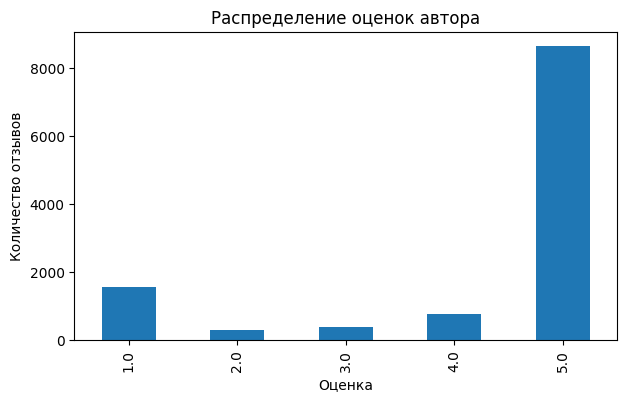

In [5]:
display(df['rating'].value_counts().sort_index())

plt.figure(figsize=(7,4))
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение оценок автора')
plt.xlabel('Оценка')
plt.ylabel('Количество отзывов')
plt.show()

,0
Сервис,5314
Доставка,4222
Качество,3397
Цена,3317
Возвраты/претензии,680
Описание,510


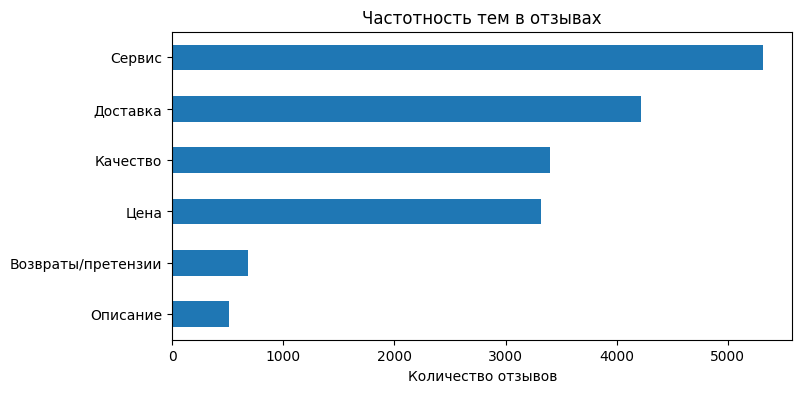

In [6]:
topic_cols = {
    'Сервис':'cat_service', 'Качество':'cat_quality', 'Доставка':'cat_delivery',
    'Описание':'cat_description_mismatch', 'Возвраты/претензии':'cat_return_claim', 'Цена':'cat_price'
}
topic_counts = pd.Series({name: int(df[col].sum()) for name, col in topic_cols.items()}).sort_values(ascending=False)
display(topic_counts)

topic_counts.sort_values().plot(kind='barh', figsize=(8,4))
plt.title('Частотность тем в отзывах')
plt.xlabel('Количество отзывов')
plt.show()

## 5. Проверка гипотез

### Гипотеза 1: Клиенты чаще оставляют негативные отзывы из-за сервиса, а не из-за качества мебели

,Метрика,Значение
0,Негативных отзывов,1.845000e+03
1,Упоминание сервиса,1.005000e+03
2,Упоминание качества,5.390000e+02
3,Только сервис,6.870000e+02
4,Только качество,2.210000e+02
5,p-value binomial,1.457278e-56


Доля сервиса: 54.5%; доля качества: 29.2%


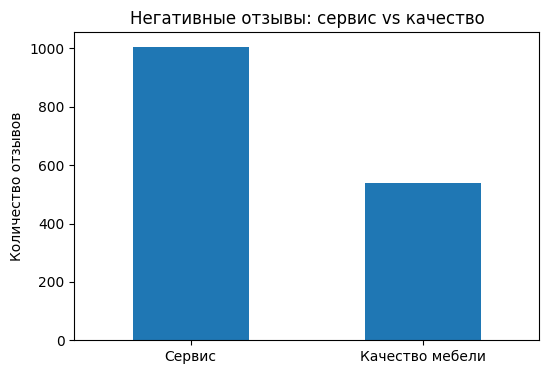

In [7]:
neg = df[df['rating'] <= 2].copy()
service = neg['cat_service']
quality = neg['cat_quality']

both = int((service & quality).sum())
serv_only = int((service & ~quality).sum())
qual_only = int((~service & quality).sum())
neither = int((~service & ~quality).sum())

p_binom = st.binomtest(serv_only, serv_only + qual_only, 0.5, alternative='greater').pvalue

h1 = pd.DataFrame({
    'Метрика':['Негативных отзывов','Упоминание сервиса','Упоминание качества','Только сервис','Только качество','p-value binomial'],
    'Значение':[len(neg), service.sum(), quality.sum(), serv_only, qual_only, p_binom]
})
display(h1)
print(f'Доля сервиса: {service.mean():.1%}; доля качества: {quality.mean():.1%}')

pd.Series({'Сервис': service.sum(), 'Качество мебели': quality.sum()}).plot(kind='bar', figsize=(6,4))
plt.title('Негативные отзывы: сервис vs качество')
plt.ylabel('Количество отзывов')
plt.xticks(rotation=0)
plt.show()

**Вывод:** гипотеза подтверждается: в негативных отзывах сервис встречается заметно чаще качества мебели.

### Гипотеза 2: Высокая скорость доставки доставки значительно повышает вероятность получения положительной оценки

,Группа,Количество отзывов,Средняя оценка,Доля положительных оценок 4-5
0,Быстрая доставка,1970,4.607107,0.901015
1,Медленная доставка,1433,3.334962,0.568039


z-test p-value: 0; Mann-Whitney p-value: 5.5e-115


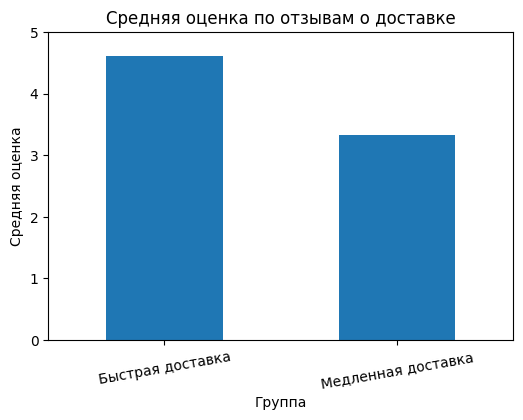

In [8]:
fast = df[df['delivery_fast']]
slow = df[df['delivery_slow']]

pfast = (fast['rating'] >= 4).mean()
pslow = (slow['rating'] >= 4).mean()
p_pool = ((fast['rating'] >= 4).sum() + (slow['rating'] >= 4).sum()) / (len(fast) + len(slow))
z = (pfast - pslow) / sqrt(p_pool * (1 - p_pool) * (1 / len(fast) + 1 / len(slow)))
p_z = 2 * (1 - st.norm.cdf(abs(z)))
u, p_u = st.mannwhitneyu(fast['rating'], slow['rating'], alternative='greater')

h2 = pd.DataFrame({
    'Группа':['Быстрая доставка','Медленная доставка'],
    'Количество отзывов':[len(fast), len(slow)],
    'Средняя оценка':[fast['rating'].mean(), slow['rating'].mean()],
    'Доля положительных оценок 4-5':[pfast, pslow]
})
display(h2)
print(f'z-test p-value: {p_z:.3g}; Mann-Whitney p-value: {p_u:.3g}')

h2.plot(x='Группа', y='Средняя оценка', kind='bar', legend=False, figsize=(6,4))
plt.title('Средняя оценка по отзывам о доставке')
plt.ylabel('Средняя оценка')
plt.ylim(0,5)
plt.xticks(rotation=10)
plt.show()

**Вывод:** гипотеза подтверждается: отзывы с быстрой доставкой имеют более высокую среднюю оценку и долю положительных отзывов.

### Гипотеза 3: Наиболее частая причина возвратов и претензий — несоответствие товара описанию

,0
Доставка,430
Сервис,403
Качество,282
Цена,212
Несоответствие описанию,87


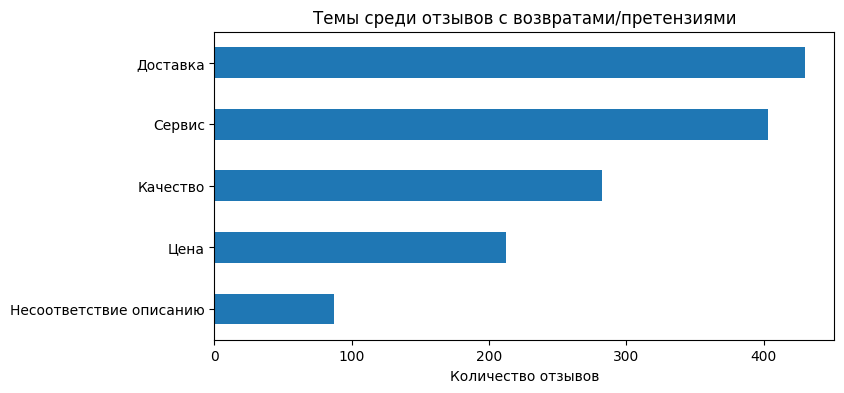

In [9]:
claims = df[df['cat_return_claim']]
claim_topics = pd.Series({
    'Доставка': claims['cat_delivery'].sum(),
    'Сервис': claims['cat_service'].sum(),
    'Качество': claims['cat_quality'].sum(),
    'Цена': claims['cat_price'].sum(),
    'Несоответствие описанию': claims['cat_description_mismatch'].sum(),
}).sort_values(ascending=False)

display(claim_topics)
claim_topics.sort_values().plot(kind='barh', figsize=(8,4))
plt.title('Темы среди отзывов с возвратами/претензиями')
plt.xlabel('Количество отзывов')
plt.show()

**Вывод:** гипотеза не подтверждается: среди отзывов с претензиями/возвратами чаще встречаются доставка и сервис, а несоответствие описанию — не основная тема.

### Гипотеза 4: Покупатели мягкой мебели (диваны, кресла) оставляют более эмоциональные и длинные отзывы по сравнению с покупателями корпусной мебели

,Группа,Количество отзывов,"Средняя длина, слов",Средняя эмоциональность
0,Мягкая мебель,1875,42.302400,2.659733
1,Корпусная мебель,3446,53.048172,3.084446


p-value для большей длины мягкой мебели: 1
p-value для большей эмоциональности мягкой мебели: 1


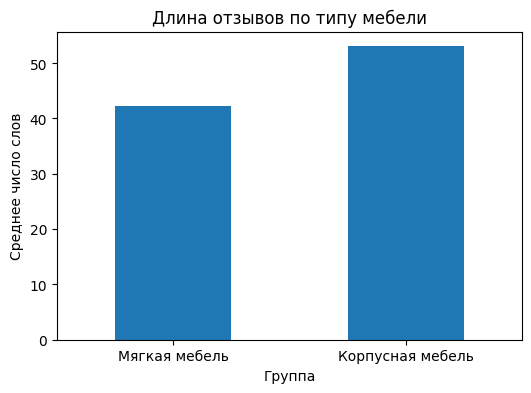

In [10]:
soft = df[df['furniture_soft'] & ~df['furniture_case']]
case = df[df['furniture_case'] & ~df['furniture_soft']]

t_len, p_len = st.ttest_ind(soft['word_count'], case['word_count'], equal_var=False, alternative='greater')
t_em, p_em = st.ttest_ind(soft['emotion_score'], case['emotion_score'], equal_var=False, alternative='greater')

h4 = pd.DataFrame({
    'Группа':['Мягкая мебель','Корпусная мебель'],
    'Количество отзывов':[len(soft), len(case)],
    'Средняя длина, слов':[soft['word_count'].mean(), case['word_count'].mean()],
    'Средняя эмоциональность':[soft['emotion_score'].mean(), case['emotion_score'].mean()]
})
display(h4)
print(f'p-value для большей длины мягкой мебели: {p_len:.3g}')
print(f'p-value для большей эмоциональности мягкой мебели: {p_em:.3g}')

h4.plot(x='Группа', y='Средняя длина, слов', kind='bar', legend=False, figsize=(6,4))
plt.title('Длина отзывов по типу мебели')
plt.ylabel('Среднее число слов')
plt.xticks(rotation=0)
plt.show()

**Вывод:** гипотеза не подтверждается: отзывы о корпусной мебели в среднем длиннее и чуть эмоциональнее.

### Гипотеза 5: Чем выше цена товара, тем более подробный отзыв оставляет клиент

In [11]:

print('В исходных данных нет фактической цены товара или заказа.')


В исходных данных нет фактической цены товара или заказа.


**Вывод:** гипотезу невозможно проверить напрямую, потому что в датасете нет числовой цены товара. Упоминание цены можно использовать только как дополнительный текстовый признак, но не как замену фактической стоимости.

## 6. Итоговая таблица гипотез

In [12]:
summary = pd.DataFrame({
    'Гипотеза':[
        'Негатив чаще из-за сервиса, чем качества',
        'Быстрая доставка повышает положительную оценку',
        'Основная причина возвратов — несоответствие описанию',
        'Мягкая мебель — более эмоциональные и длинные отзывы',
        'Чем выше цена, тем подробнее отзыв'
    ],
    'Вердикт':['Подтверждается','Подтверждается','Не подтверждается','Не подтверждается','Невозможно проверить напрямую'],
    'Ключевые цифры':[
        f'Негативных отзывов: {len(neg)}; сервис: {service.sum()} ({service.mean():.1%}); качество: {quality.sum()} ({quality.mean():.1%}); p={p_binom:.2e}',
        f'Быстрая доставка: n={len(fast)}, средняя={fast.rating.mean():.2f}, позитивных={pfast:.1%}; медленная: n={len(slow)}, средняя={slow.rating.mean():.2f}, позитивных={pslow:.1%}',
        f'Среди претензий/возвратов n={len(claims)}: доставка {claim_topics["Доставка"]}, сервис {claim_topics["Сервис"]}, качество {claim_topics["Качество"]}, описание {claim_topics["Несоответствие описанию"]}',
        f'Мягкая: n={len(soft)}, длина={soft.word_count.mean():.1f}, эмоц.={soft.emotion_score.mean():.2f}; корпусная: n={len(case)}, длина={case.word_count.mean():.1f}, эмоц.={case.emotion_score.mean():.2f}',
        'Нет фактической цены товара; нужна выгрузка заказов/каталога/чеков.'
    ]
})
display(summary)

,Гипотеза,Вердикт,Ключевые цифры
0,"Негатив чаще из-за сервиса, чем качества",Подтверждается,Негативных отзывов: 1845; сервис: 1005 (54.5%); качество: 539 (29.2%); p=1.46e-56
1,Быстрая доставка повышает положительную оценку,Подтверждается,"Быстрая доставка: n=1970, средняя=4.61, позитивных=90.1%; медленная: n=1433, средняя=3.33, позитивных=56.8%"
2,Основная причина возвратов — несоответствие описанию,Не подтверждается,"Среди претензий/возвратов n=680: доставка 430, сервис 403, качество 282, описание 87"
3,Мягкая мебель — более эмоциональные и длинные отзывы,Не подтверждается,"Мягкая: n=1875, длина=42.3, эмоц.=2.66; корпусная: n=3446, длина=53.0, эмоц.=3.08"
4,"Чем выше цена, тем подробнее отзыв",Невозможно проверить напрямую,Нет фактической цены товара; нужна выгрузка заказов/каталога/чеков.


In [13]:
cols_for_bi = [
    'Источник','Наименование','Адрес','Автор','Дата','Оценка автора','rating','sentiment_by_rating','text',
    'word_count','char_count','exclamations','emoji_count','emotion_words','emotion_score',
    'cat_service','cat_quality','cat_delivery','delivery_fast','delivery_slow',
    'cat_description_mismatch','cat_return_claim','cat_price','furniture_soft','furniture_case'
]

df[cols_for_bi].to_csv('reviews_clean_for_bi.csv', index=False, encoding='utf-8-sig')
summary.to_csv('hypotheses_summary.csv', index=False, encoding='utf-8-sig')
print('Файлы сохранены: reviews_clean_for_bi.csv, hypotheses_summary.csv')

Файлы сохранены: reviews_clean_for_bi.csv, hypotheses_summary.csv


Доработка Гипотезы 2
Детализация по скорости доставки и типу мебели:


rating        sentiment_by_rating
                               count   mean            <lambda>
delivery_speed furniture_soft                                  
Быстрая        False            1235  4.829               0.960
               True              326  4.672               0.920
Медленная      False             936  3.216               0.541
               True              497  3.559               0.620


Mann-Whitney p-value: 1.10e-114
Cohen's d = 0.821 


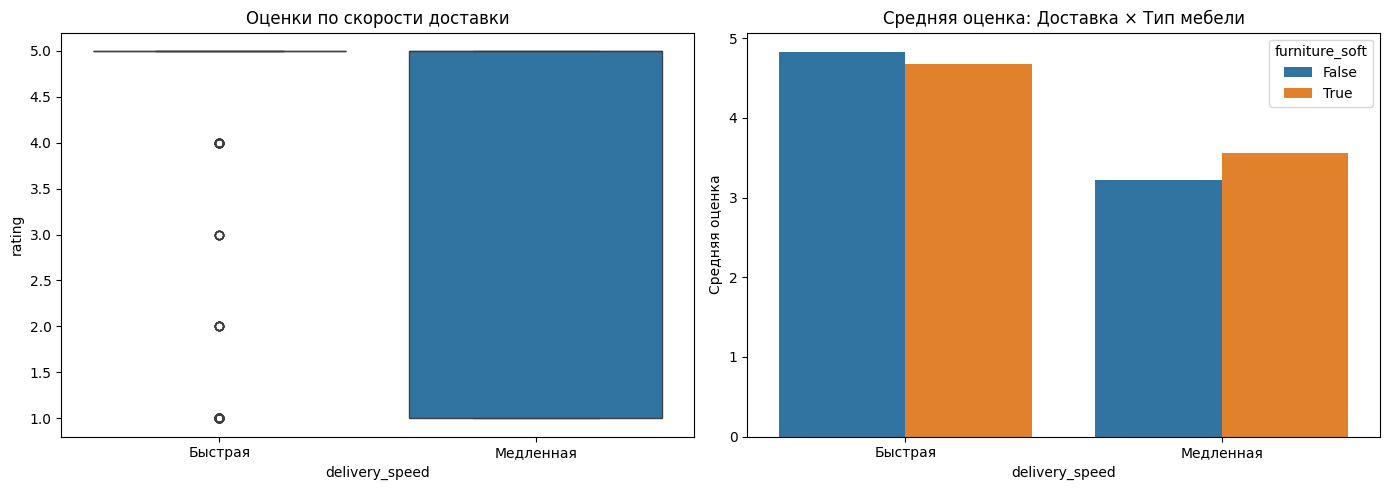

In [14]:
print("Доработка Гипотезы 2")

df['delivery_speed'] = 'Нет упоминаний'
df.loc[df['delivery_fast'], 'delivery_speed'] = 'Быстрая'
df.loc[df['delivery_slow'], 'delivery_speed'] = 'Медленная'


detail = df[df['delivery_speed'] != 'Нет упоминаний'].groupby(['delivery_speed', 'furniture_soft']).agg({
    'rating': ['count', 'mean'],
    'sentiment_by_rating': lambda x: (x == 'positive').mean()
}).round(3)

print("Детализация по скорости доставки и типу мебели:")
display(detail)


from scipy.stats import mannwhitneyu
import numpy as np

fast = df[df['delivery_fast']]['rating'].dropna()
slow = df[df['delivery_slow']]['rating'].dropna()

mw_stat, p_mw = mannwhitneyu(fast, slow)
d = (fast.mean() - slow.mean()) / np.sqrt((fast.var() + slow.var()) / 2)

print(f"\nMann-Whitney p-value: {p_mw:.2e}")
print(f"Cohen's d = {d:.3f} ")

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df[df['delivery_speed'] != 'Нет упоминаний'],
            x='delivery_speed', y='rating', ax=axes[0])
axes[0].set_title('Оценки по скорости доставки')

sns.barplot(data=detail.reset_index(), x='delivery_speed', y=('rating', 'mean'),
            hue='furniture_soft', ax=axes[1])
axes[1].set_title('Средняя оценка: Доставка × Тип мебели')
axes[1].set_ylabel('Средняя оценка')

plt.tight_layout()
plt.show()